In [4]:
# exp8_F_with_exp81_S_and_D_full_fixed.py
#
# Fixes:
# 1) loads exp8 forecaster correctly (GridAgnostic1D with stem/b1..b5/scalar_proj/head)
# 2) fixes shape bugs: DataLoader future_raw is [B,K,N], not [K,N]
# 3) evaluates F-only and F+S with:
#    - numerical: mseK_unif, rollout_rmse_mean, rollout_rmse_final
#    - distribution: spectrum_mse, coherence, structure_grad_mse, hf_ratio_err
# 4) trains exp8.1-style Stabilizer S + PatchCritic D (WGAN-GP) on top of frozen exp8 F
#
# You only need to change:
#   DATA_DIR, FORECASTER_CKPT, OUT_DIR
#
# Run as a standalone script or paste into a notebook cell.

import os, math, random, time
from pathlib import Path
from typing import Dict, Tuple, Optional

import numpy as np
import torch
import torch.nn as nn

# -----------------------
# user config
# -----------------------
DATA_DIR = Path("/scratch/pp3051/weather")

# exp8 forecaster checkpoint (the one you want to use as F)
FORECASTER_CKPT = Path("/scratch/pp3051/weather/runs_grid_agnostic_closed_loop_exp8_stable/best_currK.pt")

OUT_DIR = Path("/scratch/pp3051/weather/runs_exp8F_exp81GAN")
OUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 1337

# -----------------------
# training config
# -----------------------
FREQS = (1, 2, 4, 8)
DIVISORS = (1, 2, 4)

K_MAX = 8          # how many future steps your dataset provides
K_ROLL = 8         # rollout length for training/eval of stabilizer
BATCH_SIZE = 64
NUM_WORKERS = 2

STAB_STEPS = 20_000
N_CRITIC = 2
LR_S = 2e-4
LR_D = 2e-4
GP_LAMBDA = 10.0
LAMBDA_ADV = 0.02

LOG_EVERY = 50
EVAL_EVERY = 500
MAX_VAL_BATCHES = 20

# exp8/8.1 loss weights (same style as exp8.1)
BETA_DU      = 0.50
LAMBDA_GRAD  = 0.05
LAMBDA_STATS = 0.001
LAMBDA_FFT   = 0.02
LAMBDA_COH   = 0.01

# exp8.1 stabilizer behavior
INCLUDE_DU_BASE = True        # S sees du_base_n as input (like exp8.1)
TBPTT_DETACH = True           # detach hidden state each rollout step (like exp8.1-ish)

FFT_NORM = "ortho"


# -----------------------
# reproducibility
# -----------------------
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


# -----------------------
# io helpers (matches your notebook style)
# -----------------------
def load_supervised_pairs(data_dir: Path):
    Xtr = np.load(data_dir / "X_train.npy").astype(np.float32, copy=False)
    Ytr = np.load(data_dir / "y_train.npy").astype(np.float32, copy=False)
    Xva = np.load(data_dir / "X_val.npy").astype(np.float32, copy=False)
    Yva = np.load(data_dir / "y_val.npy").astype(np.float32, copy=False)
    Xte = np.load(data_dir / "X_test.npy").astype(np.float32, copy=False)
    Yte = np.load(data_dir / "y_test.npy").astype(np.float32, copy=False)
    return Xtr, Ytr, Xva, Yva, Xte, Yte

def try_load_x_t(data_dir: Path):
    x = None; t = None
    for cand in ["ks_spatial_grid.npy", "x.npy", "ks_spatial_grid1.npy"]:
        p = data_dir / cand
        if p.exists():
            x = np.load(p).astype(np.float32)
            break
    for cand in ["ks_time.npy", "t.npy"]:
        p = data_dir / cand
        if p.exists():
            t = np.load(p).astype(np.float32)
            break
    return x, t

def infer_Lx_dt_from_xt(x, t):
    if x is not None:
        Lx = float((x[1] - x[0]) * len(x))
    else:
        # fallback if x not present
        Lx = 2 * math.pi
    dt = None
    if t is not None and len(t) >= 2:
        dt = float(t[1] - t[0])
    return Lx, dt


# -----------------------
# downsample + positional encoding (exp8 style)
# -----------------------
def area_average_downsample_batch(u_hi: np.ndarray, Nx_lo: int):
    Nx_hi = u_hi.shape[-1]
    assert Nx_hi % Nx_lo == 0
    r = Nx_hi // Nx_lo
    new_shape = u_hi.shape[:-1] + (Nx_lo, r)
    return u_hi.reshape(new_shape).mean(axis=-1, dtype=np.float32)

def posenc_from_x(x: np.ndarray, freqs):
    x_min = float(x.min()); x_max = float(x.max())
    x01 = (x - x_min) / max(1e-12, x_max - x_min)
    N = x01.shape[0]
    feats = np.zeros((2 * len(freqs), N), dtype=np.float32)
    for i, f in enumerate(freqs):
        ang = 2 * math.pi * f * x01
        feats[2*i]   = np.sin(ang).astype(np.float32)
        feats[2*i+1] = np.cos(ang).astype(np.float32)
    return feats

def _rfft(u):
    # u: [B,1,N] -> complex [B,1,Nf]
    return torch.fft.rfft(u, dim=-1, norm=FFT_NORM)

def fft_mag(u):
    return torch.abs(_rfft(u))

def circular_grad(u):
    return torch.roll(u, shifts=-1, dims=-1) - u

def weighted_mse(pred, target, width):
    # pred/target: [B,1,N], width: [B,N]
    diff2 = (pred - target).square()
    w = width.unsqueeze(1)
    return (diff2 * w).sum() / w.sum().clamp_min(1e-8)

def fft_coherence_loss(u_pred, u_true, eps=1e-8):
    """
    1 - Re( Zp * conj(Zt) / (|Zp||Zt| + eps) ), lightly upweight higher freqs.
    """
    Zp = _rfft(u_pred)
    Zt = _rfft(u_true)
    num = (Zp * torch.conj(Zt)).real
    den = (torch.abs(Zp) * torch.abs(Zt)).clamp_min(eps)
    coh = 1.0 - (num / den)  # [B,1,Nf]
    nf = coh.shape[-1]
    wfreq = torch.linspace(0.5, 1.5, nf, device=coh.device)[None, None, :]
    return (coh * wfreq).mean()

@torch.no_grad()
def coherence_metric(u_pred, u_true, eps=1e-8):
    # returns mean coherence in [0,1]-ish
    Zp = _rfft(u_pred)
    Zt = _rfft(u_true)
    num = torch.abs(torch.mean(Zp * torch.conj(Zt), dim=0))
    den = torch.sqrt(torch.mean(torch.abs(Zp) ** 2, dim=0) * torch.mean(torch.abs(Zt) ** 2, dim=0) + eps)
    coh = (num / den).mean()
    return coh

@torch.no_grad()
def hf_energy_ratio(u, hf_start_frac=0.25, eps=1e-8):
    mag = fft_mag(u)  # [B,1,Nf]
    nf = mag.shape[-1]
    k0 = int(hf_start_frac * nf)
    hf = (mag[..., k0:] ** 2).sum(dim=-1)
    tot = (mag ** 2).sum(dim=-1) + eps
    return (hf / tot).mean()


# -----------------------
# norms (exp8 style)
# -----------------------
def compute_norms_per_divisor(X: np.ndarray, divisors):
    norms = {}
    N0 = X.shape[1]
    for d in divisors:
        N = N0 // d
        U = X
        if d != 1:
            U = area_average_downsample_batch(U, N)
        u_mean = float(U.mean())
        u_std  = float(U.std() + 1e-8)
        DU = U[1:] - U[:-1]
        du_mean = float(DU.mean())
        du_std  = float(DU.std() + 1e-8)
        norms[d] = (u_mean, u_std, du_mean, du_std)
        print(f"[norm d={d}] u_mean={u_mean:.4g} u_std={u_std:.4g} | du_mean={du_mean:.4g} du_std={du_std:.4g}")
    return norms


# -----------------------
# dataset (fixed shapes)
# -----------------------
class ClosedLoopDataset(torch.utils.data.Dataset):
    """
    Uses X as a contiguous time series.
    Returns:
      profiles_raw: [Cin, N]   (3 u-channels + pe channels)
      future_raw:   [Kmax, N]  (u(t+1..t+K))
      width:        [N]
      scalars:      [S]
    DataLoader makes:
      profiles_raw: [B,Cin,N]
      future_raw:   [B,Kmax,N]
      width:        [B,N]
      scalars:      [B,S]
    """
    def __init__(self, X: np.ndarray, K_max: int, divisor: int, Lx: float, dt: Optional[float],
                 scalar_dim: int, freqs=FREQS):
        super().__init__()
        self.X0 = X
        self.K_max = int(K_max)
        self.divisor = int(divisor)
        self.Lx = float(Lx)
        self.dt = dt
        self.scalar_dim = int(scalar_dim)

        self.N0 = int(X.shape[1])
        assert self.N0 % self.divisor == 0
        self.N = self.N0 // self.divisor

        self.dx = self.Lx / self.N
        self.width = np.full(self.N, self.dx, dtype=np.float32)

        x = (np.arange(self.N, dtype=np.float32) + 0.5) * self.dx
        self.pe = posenc_from_x(x, freqs).astype(np.float32)  # [2*len(freqs), N]

        # valid indices: need i-2 >= 0 and i+K_max <= len(X)-1
        self.valid = np.arange(2, len(self.X0) - self.K_max - 1, dtype=np.int64)

    def __len__(self):
        return int(self.valid.shape[0])

    def _down(self, u: np.ndarray):
        if self.divisor == 1:
            return u.astype(np.float32, copy=False)
        # u can be [N0] or [K,N0]
        if u.ndim == 1:
            return area_average_downsample_batch(u[None, :], self.N)[0]
        return area_average_downsample_batch(u, self.N)

    def _make_scalars(self):
        # scalar order (most likely in your training): [Lx] + [dt if present] + [dx]
        if self.scalar_dim == 3:
            dtt = float(self.dt) if self.dt is not None else 0.0
            return np.array([self.Lx, dtt, float(self.dx)], dtype=np.float32)
        if self.scalar_dim == 2:
            # most common for grid-agnostic: [Lx, dx]
            return np.array([self.Lx, float(self.dx)], dtype=np.float32)
        return np.array([self.Lx], dtype=np.float32)

    def __getitem__(self, j: int):
        i = int(self.valid[j])
        u_tm2 = self._down(self.X0[i-2])
        u_tm1 = self._down(self.X0[i-1])
        u_t   = self._down(self.X0[i])
        futures = self._down(self.X0[i+1:i+1+self.K_max])  # [Kmax, N]

        profiles = np.concatenate([u_tm2[None], u_tm1[None], u_t[None], self.pe], axis=0).astype(np.float32)
        scalars = self._make_scalars()

        return {
            "profiles_raw": profiles,     # [Cin, N]
            "future_raw": futures,        # [Kmax, N]
            "width": self.width,          # [N]
            "scalars": scalars,           # [S]
        }


# -----------------------
# exp8 forecaster (correct architecture for your checkpoint keys)
# -----------------------
class BatchOrLayerNorm1d(nn.Module):
    def __init__(self, num_features, norm_type="batch"):
        super().__init__()
        self.norm_type = norm_type
        if norm_type == "batch":
            self.bn = nn.BatchNorm1d(num_features)
            self.ln = None
        elif norm_type == "layer":
            self.ln = nn.LayerNorm(num_features)
            self.bn = None
        else:
            raise ValueError("norm_type must be 'batch' or 'layer'")

    def forward(self, x):
        if self.norm_type == "batch":
            return self.bn(x)
        x_perm = x.permute(0, 2, 1)      # [B,L,C]
        x_norm = self.ln(x_perm)
        return x_norm.permute(0, 2, 1)

class ResidualDilated1D(nn.Module):
    def __init__(self, ch, d, norm_type, dropout_p):
        super().__init__()
        self.conv1 = nn.Conv1d(ch, ch, 3, padding=d, dilation=d, padding_mode="circular", bias=False)
        self.norm1 = BatchOrLayerNorm1d(ch, norm_type=norm_type)
        self.act1  = nn.SiLU(inplace=True)
        self.drop1 = nn.Dropout(p=dropout_p)

        self.conv2 = nn.Conv1d(ch, ch, 3, padding=1, dilation=1, padding_mode="circular", bias=False)
        self.norm2 = BatchOrLayerNorm1d(ch, norm_type=norm_type)
        self.act2  = nn.SiLU(inplace=True)
        self.drop2 = nn.Dropout(p=dropout_p)

    def forward(self, x):
        y = self.drop1(self.act1(self.norm1(self.conv1(x))))
        y = self.drop2(self.norm2(self.conv2(y)))
        return self.act2(x + y)

class GridAgnostic1D(nn.Module):
    def __init__(self, cin, scalar_dim, hidden=96, norm_type="batch", dropout_p=0.0, du_clip_n=5.0):
        super().__init__()
        self.du_clip_n = float(du_clip_n)

        self.stem = nn.Sequential(
            nn.Conv1d(cin, hidden, 3, padding=1, padding_mode="circular", bias=False),
            BatchOrLayerNorm1d(hidden, norm_type=norm_type),
            nn.SiLU(inplace=True),
            nn.Dropout(p=dropout_p),
        )

        self.b1 = ResidualDilated1D(hidden, 1,  norm_type, dropout_p)
        self.b2 = ResidualDilated1D(hidden, 2,  norm_type, dropout_p)
        self.b3 = ResidualDilated1D(hidden, 4,  norm_type, dropout_p)
        self.b4 = ResidualDilated1D(hidden, 8,  norm_type, dropout_p)
        self.b5 = ResidualDilated1D(hidden, 16, norm_type, dropout_p)

        self.scalar_proj = nn.Sequential(
            nn.Linear(scalar_dim, 128),
            nn.SiLU(inplace=True),
            nn.Dropout(p=dropout_p),
            nn.Linear(128, 32),
            nn.SiLU(inplace=True),
        )

        self.head = nn.Sequential(
            nn.Conv1d(hidden + 32, hidden, 1),
            BatchOrLayerNorm1d(hidden, norm_type=norm_type),
            nn.SiLU(inplace=True),
            nn.Dropout(p=dropout_p),
            nn.Conv1d(hidden, 1, 1),
        )

    def forward(self, profiles, scalars):
        h = self.stem(profiles)
        h = self.b5(self.b4(self.b3(self.b2(self.b1(h)))))
        B, C, N = h.shape
        s = self.scalar_proj(scalars)[:, :, None].expand(B, 32, N)
        h = torch.cat([h, s], dim=1)
        out = self.head(h)
        c = self.du_clip_n
        if c > 0:
            out = c * torch.tanh(out / c)
        return out


# -----------------------
# exp8.1 Stabilizer + PatchCritic (exact style)
# -----------------------
class Stabilizer1D(nn.Module):
    def __init__(
        self,
        cin_hist: int,
        scalar_dim: int,
        hidden: int = 96,
        norm_type: str = "batch",
        dropout_p: float = 0.10,
        du_corr_clip_n: float = 2.0,
    ):
        super().__init__()
        self.du_corr_clip_n = float(du_corr_clip_n)

        self.stem = nn.Sequential(
            nn.Conv1d(cin_hist, hidden, 3, padding=1, padding_mode="circular", bias=False),
            BatchOrLayerNorm1d(hidden, norm_type=norm_type),
            nn.SiLU(inplace=True),
            nn.Dropout(p=dropout_p),
        )

        self.b1 = ResidualDilated1D(hidden, 1, norm_type, dropout_p)
        self.b2 = ResidualDilated1D(hidden, 2, norm_type, dropout_p)
        self.b3 = ResidualDilated1D(hidden, 4, norm_type, dropout_p)
        self.b4 = ResidualDilated1D(hidden, 8, norm_type, dropout_p)

        self.scalar_proj = nn.Sequential(
            nn.Linear(scalar_dim, 64),
            nn.SiLU(inplace=True),
            nn.Dropout(p=dropout_p),
            nn.Linear(64, 16),
            nn.SiLU(inplace=True),
        )

        self.head = nn.Sequential(
            nn.Conv1d(hidden + 16, hidden, 1),
            BatchOrLayerNorm1d(hidden, norm_type=norm_type),
            nn.SiLU(inplace=True),
            nn.Dropout(p=dropout_p),
            nn.Conv1d(hidden, 1, 1),
        )

    def forward(self, x, scalars):
        h = self.stem(x)
        h = self.b4(self.b3(self.b2(self.b1(h))))
        B, C, N = h.shape
        s = self.scalar_proj(scalars)[:, :, None].expand(B, 16, N)
        h = torch.cat([h, s], dim=1)
        du_corr_n = self.head(h)
        c = self.du_corr_clip_n
        if c > 0:
            du_corr_n = c * torch.tanh(du_corr_n / c)
        return du_corr_n

class PatchCritic1D(nn.Module):
    def __init__(self, cin: int, scalar_dim: int, hidden: int = 64, dropout_p: float = 0.0):
        super().__init__()
        self.scalar_proj = nn.Sequential(
            nn.Linear(scalar_dim, 32),
            nn.SiLU(inplace=True),
            nn.Linear(32, 8),
            nn.SiLU(inplace=True),
        )

        def block(c_in, c_out, k=5, s=2, p=2):
            return nn.Sequential(
                nn.Conv1d(c_in, c_out, k, stride=s, padding=p, padding_mode="circular", bias=True),
                nn.LeakyReLU(0.2, inplace=True),
            )

        self.net = nn.Sequential(
            block(cin + 8, hidden,    5, 2, 2),
            block(hidden, hidden*2,   5, 2, 2),
            block(hidden*2, hidden*4, 5, 2, 2),
            nn.Conv1d(hidden*4, 1, 3, padding=1, padding_mode="circular", bias=True),
        )
        self.drop = nn.Dropout(p=dropout_p) if dropout_p > 0 else nn.Identity()

    def forward(self, x, scalars):
        B, C, N = x.shape
        s = self.scalar_proj(scalars)[:, :, None].expand(B, 8, N)
        h = torch.cat([x, s], dim=1)
        h = self.drop(h)
        return self.net(h)  # [B,1,Np]

def wgan_gp_gradient_penalty(D, x_cond, scalars, u_next_real_n, u_next_fake_n, gp_lambda=10.0):
    B = u_next_real_n.shape[0]
    eps = torch.rand((B, 1, 1), device=u_next_real_n.device, dtype=u_next_real_n.dtype)
    u_hat = eps * u_next_real_n + (1.0 - eps) * u_next_fake_n
    x_hat = torch.cat([x_cond, u_hat], dim=1).requires_grad_(True)

    score = D(x_hat, scalars).mean()
    grads = torch.autograd.grad(
        outputs=score,
        inputs=x_hat,
        grad_outputs=torch.ones_like(score),
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]
    grads = grads.reshape(B, -1)
    gp = ((grads.norm(2, dim=1) - 1.0) ** 2).mean()
    return gp_lambda * gp

def build_stab_input(u_tm2_n, u_tm1_n, u_t_n, pe, du_base_n=None):
    if du_base_n is None:
        return torch.cat([u_tm2_n, u_tm1_n, u_t_n, pe], dim=1)
    return torch.cat([u_tm2_n, u_tm1_n, u_t_n, du_base_n, pe], dim=1)


# -----------------------
# loss terms + metrics (fixed shapes)
# -----------------------
def step_loss_terms(u_pred, u_true, u_in, du_pred, width):
    # all physical units
    loss_u = weighted_mse(u_pred, u_true, width)
    du_true = (u_true - u_in)
    loss_du = weighted_mse(du_pred, du_true, width)
    loss_g = weighted_mse(circular_grad(u_pred), circular_grad(u_true), width) if LAMBDA_GRAD > 0 else torch.tensor(0.0, device=u_pred.device)
    if LAMBDA_STATS > 0:
        mu_p = u_pred.mean(dim=-1); mu_t = u_true.mean(dim=-1)
        sig_p = u_pred.std(dim=-1);  sig_t = u_true.std(dim=-1)
        loss_stats = (mu_p - mu_t).pow(2).mean() + (sig_p - sig_t).pow(2).mean()
    else:
        loss_stats = torch.tensor(0.0, device=u_pred.device)
    if LAMBDA_FFT > 0:
        mp = fft_mag(u_pred)
        mt = fft_mag(u_true)
        nf = mp.shape[-1]
        wfreq = torch.linspace(0.5, 1.5, nf, device=mp.device)[None, None, :]
        loss_fft = ((mp - mt).square() * wfreq).mean()
    else:
        loss_fft = torch.tensor(0.0, device=u_pred.device)
    if LAMBDA_COH > 0:
        loss_coh = fft_coherence_loss(u_pred, u_true)
    else:
        loss_coh = torch.tensor(0.0, device=u_pred.device)
    return loss_u, loss_du, loss_g, loss_stats, loss_fft, loss_coh

def mix_losses(loss_u, loss_du, loss_g, loss_stats, loss_fft, loss_coh):
    out = (1.0 - BETA_DU) * loss_u + BETA_DU * loss_du
    out = out + LAMBDA_GRAD * loss_g + LAMBDA_STATS * loss_stats + LAMBDA_FFT * loss_fft + LAMBDA_COH * loss_coh
    return out

@torch.no_grad()
def eval_metrics_from_rollouts(u_true_seq, u_pred_seq):
    """
    u_true_seq/u_pred_seq: [K,B,1,N]
    returns dict of scalars
    """
    mse = (u_true_seq - u_pred_seq).square().mean()

    rmse_each = torch.sqrt((u_true_seq - u_pred_seq).square().mean(dim=(2,3)))  # [K,B]
    rmse_mean = rmse_each.mean()
    rmse_final = rmse_each[-1].mean()

    # structure: gradient mse
    gt = circular_grad(u_true_seq.reshape(-1, 1, u_true_seq.shape[-1]))
    gp = circular_grad(u_pred_seq.reshape(-1, 1, u_pred_seq.shape[-1]))
    grad_mse = (gt - gp).square().mean()

    # spectrum mse
    spec_mses = []
    for k in range(u_true_seq.shape[0]):
        mt = fft_mag(u_true_seq[k])
        mp = fft_mag(u_pred_seq[k])
        spec_mses.append((mt - mp).square().mean())
    spectrum_mse = torch.stack(spec_mses).mean()

    # coherence metric (higher better)
    cohs = []
    for k in range(u_true_seq.shape[0]):
        cohs.append(coherence_metric(u_pred_seq[k], u_true_seq[k]))
    coh = torch.stack(cohs).mean()

    # hf ratio error
    hf_t = torch.stack([hf_energy_ratio(u_true_seq[k]) for k in range(u_true_seq.shape[0])]).mean()
    hf_p = torch.stack([hf_energy_ratio(u_pred_seq[k]) for k in range(u_pred_seq.shape[0])]).mean()
    hf_err = (hf_t - hf_p).abs()

    return {
        "mseK_unif": float(mse.item()),
        "rollout_rmse_mean": float(rmse_mean.item()),
        "rollout_rmse_final": float(rmse_final.item()),
        "spectrum_mse": float(spectrum_mse.item()),
        "coherence": float(coh.item()),
        "structure_grad_mse": float(grad_mse.item()),
        "hf_ratio_err": float(hf_err.item()),
    }


# -----------------------
# checkpoint loading (auto-infer cin / scalar_dim / hidden / norm_type)
# -----------------------
def unwrap_state_dict(obj):
    if isinstance(obj, dict):
        for k in ["state_dict", "model", "model_state", "net"]:
            if k in obj and isinstance(obj[k], dict):
                return obj[k]
    return obj

def strip_prefix(sd: dict):
    out = {}
    for k, v in sd.items():
        nk = k
        for pref in ["module.", "model.", "forecaster."]:
            if nk.startswith(pref):
                nk = nk[len(pref):]
        out[nk] = v
    return out

def infer_model_shapes_from_ckpt(sd: dict) -> Tuple[int,int,int,str]:
    # cin, scalar_dim, hidden, norm_type
    # stem.0.weight shape = [hidden, cin, 3]
    w = sd.get("stem.0.weight", None)
    if w is None:
        raise RuntimeError("could not find stem.0.weight in checkpoint (wrong ckpt?)")
    hidden = int(w.shape[0])
    cin = int(w.shape[1])

    # scalar_proj.0.weight shape = [128, scalar_dim]
    sw = sd.get("scalar_proj.0.weight", None)
    if sw is None:
        raise RuntimeError("could not find scalar_proj.0.weight in checkpoint (wrong ckpt?)")
    scalar_dim = int(sw.shape[1])

    # norm type heuristic
    norm_type = "batch" if any(".bn." in k for k in sd.keys()) else "layer"
    return cin, scalar_dim, hidden, norm_type


# -----------------------
# exp8.1 helper: forecaster step (uses global norms)
# -----------------------
def forecaster_step(model_F, u_tm2, u_tm1, u_t, pe, scalars, divisor: int, norms: dict):
    u_mean, u_std, du_mean, du_std = norms[divisor]
    u_tm2_n = (u_tm2 - u_mean) / u_std
    u_tm1_n = (u_tm1 - u_mean) / u_std
    u_t_n   = (u_t   - u_mean) / u_std
    prof = torch.cat([u_tm2_n, u_tm1_n, u_t_n, pe], dim=1)
    du_n = model_F(prof, scalars)
    du = du_n * du_std + du_mean
    return du, du_n, (u_tm2_n, u_tm1_n, u_t_n)


# -----------------------
# evaluation (fixed, works with your DataLoader shapes)
# -----------------------
@torch.no_grad()
def eval_forecaster_rollout_metrics(model_F, loaders, norms, eval_K=8, max_batches=20):
    model_F.eval()
    agg = {k: 0.0 for k in ["mseK_unif","rollout_rmse_mean","rollout_rmse_final","spectrum_mse","coherence","structure_grad_mse","hf_ratio_err"]}
    n = 0

    for d, dl in loaders.items():
        u_mean, u_std, du_mean, du_std = norms[d]
        for bi, batch in enumerate(dl):
            if bi >= max_batches:
                break
            profiles_raw = batch["profiles_raw"].to(DEVICE)  # [B,Cin,N]
            future_raw   = batch["future_raw"].to(DEVICE)    # [B,K,N]
            scalars      = batch["scalars"].to(DEVICE)       # [B,S]

            u_tm2 = profiles_raw[:, 0:1, :]
            u_tm1 = profiles_raw[:, 1:2, :]
            u_t   = profiles_raw[:, 2:3, :]
            pe    = profiles_raw[:, 3:, :]

            u_pred_seq = []
            u_true_seq = []

            for k in range(eval_K):
                du, du_n, (u_tm2_n, u_tm1_n, u_t_n) = forecaster_step(
                    model_F, u_tm2, u_tm1, u_t, pe, scalars, divisor=d, norms=norms
                )
                u_next = u_t + du
                u_true = future_raw[:, k:k+1, :]  # [B,1,N]

                u_pred_seq.append(u_next)
                u_true_seq.append(u_true)

                u_tm2, u_tm1, u_t = u_tm1, u_t, u_next

            u_pred_seq = torch.stack(u_pred_seq, dim=0)  # [K,B,1,N]
            u_true_seq = torch.stack(u_true_seq, dim=0)  # [K,B,1,N]

            met = eval_metrics_from_rollouts(u_true_seq, u_pred_seq)
            for k, v in met.items():
                agg[k] += v
            n += 1

    for k in agg:
        agg[k] /= max(1, n)
    return agg

@torch.no_grad()
def eval_stabilized_rollout_metrics(model_F, S, loaders, norms, eval_K=8, include_du_base=True, max_batches=20):
    model_F.eval(); S.eval()
    agg = {k: 0.0 for k in ["mseK_unif","rollout_rmse_mean","rollout_rmse_final","spectrum_mse","coherence","structure_grad_mse","hf_ratio_err"]}
    n = 0

    for d, dl in loaders.items():
        u_mean, u_std, du_mean, du_std = norms[d]
        for bi, batch in enumerate(dl):
            if bi >= max_batches:
                break
            profiles_raw = batch["profiles_raw"].to(DEVICE)  # [B,Cin,N]
            future_raw   = batch["future_raw"].to(DEVICE)    # [B,K,N]
            scalars      = batch["scalars"].to(DEVICE)       # [B,S]

            u_tm2 = profiles_raw[:, 0:1, :]
            u_tm1 = profiles_raw[:, 1:2, :]
            u_t   = profiles_raw[:, 2:3, :]
            pe    = profiles_raw[:, 3:, :]

            u_pred_seq = []
            u_true_seq = []

            for k in range(eval_K):
                du_base, du_base_n, (u_tm2_n, u_tm1_n, u_t_n) = forecaster_step(
                    model_F, u_tm2, u_tm1, u_t, pe, scalars, divisor=d, norms=norms
                )
                xS = build_stab_input(u_tm2_n, u_tm1_n, u_t_n, pe, du_base_n if include_du_base else None)
                du_corr_n = S(xS, scalars)          # normalized correction
                du_corr   = du_corr_n * du_std      # centered correction (no du_mean)
                du_tot    = du_base + du_corr
                u_next    = u_t + du_tot

                u_true = future_raw[:, k:k+1, :]
                u_pred_seq.append(u_next)
                u_true_seq.append(u_true)

                u_tm2, u_tm1, u_t = u_tm1, u_t, u_next

            u_pred_seq = torch.stack(u_pred_seq, dim=0)
            u_true_seq = torch.stack(u_true_seq, dim=0)
            met = eval_metrics_from_rollouts(u_true_seq, u_pred_seq)

            for k, v in met.items():
                agg[k] += v
            n += 1

    for k in agg:
        agg[k] /= max(1, n)
    return agg


# -----------------------
# WGAN-GP training loop (exp8.1 style)
# -----------------------
def make_iter(dl):
    it = iter(dl)
    return it

def next_batch(dl, it):
    try:
        b = next(it)
        return b, it
    except StopIteration:
        it = iter(dl)
        b = next(it)
        return b, it

def train_stabilizer_wgan(
    model_F,
    train_loaders,
    val_loaders,
    norms,
    *,
    steps=20_000,
    K_roll=8,
    n_critic=2,
    lr_S=2e-4,
    lr_D=2e-4,
    gp_lambda=10.0,
    lambda_adv=0.02,
    include_du_base=True,
    log_every=100,
    eval_every=1000,
):
    # dimensions
    pe_ch = 2 * len(FREQS)
    cin_S = 3 + pe_ch + (1 if include_du_base else 0)
    cin_D_cond = 3 + pe_ch
    cin_D = cin_D_cond + 1

    # infer scalar_dim from the batch
    any_div = list(train_loaders.keys())[0]
    sample = next(iter(train_loaders[any_div]))
    scalar_dim = int(sample["scalars"].shape[-1])

    # stabilizer + critic
    S = Stabilizer1D(
        cin_hist=cin_S,
        scalar_dim=scalar_dim,
        hidden=96,
        norm_type="batch",
        dropout_p=0.10,
        du_corr_clip_n=2.0,
    ).to(DEVICE)

    D = PatchCritic1D(
        cin=cin_D,
        scalar_dim=scalar_dim,
        hidden=64,
        dropout_p=0.0,
    ).to(DEVICE)

    optS = torch.optim.AdamW(S.parameters(), lr=lr_S, betas=(0.5, 0.9), weight_decay=1e-4)
    optD = torch.optim.AdamW(D.parameters(), lr=lr_D, betas=(0.5, 0.9), weight_decay=1e-4)

    model_F.eval()
    for p in model_F.parameters():
        p.requires_grad_(False)

    # iterators per divisor
    iters = {d: iter(train_loaders[d]) for d in train_loaders.keys()}
    divs = list(train_loaders.keys())

    best_val = float("inf")

    for step in range(1, steps + 1):
        d = divs[(step - 1) % len(divs)]
        batch, iters[d] = next_batch(train_loaders[d], iters[d])

        profiles_raw = batch["profiles_raw"].to(DEVICE)  # [B,Cin,N]
        future_raw   = batch["future_raw"].to(DEVICE)    # [B,K,N]
        width        = batch["width"].to(DEVICE)         # [B,N]
        scalars      = batch["scalars"].to(DEVICE)       # [B,S]

        u_tm2 = profiles_raw[:, 0:1, :]
        u_tm1 = profiles_raw[:, 1:2, :]
        u_t   = profiles_raw[:, 2:3, :]
        pe    = profiles_raw[:, 3:, :]

        u_mean, u_std, du_mean, du_std = norms[d]

        # choose one step in rollout for adversarial
        k_adv = random.randint(0, max(0, K_roll - 1))

        sup_loss_total = torch.zeros((), device=DEVICE)

        xcond_for_gp = None
        u_real_adv_n = None
        u_fake_adv_n_detached = None
        u_fake_adv_n_for_G = None

        # ---------------- rollout (free-run) ----------------
        for k in range(K_roll):
            du_base, du_base_n, (u_tm2_n, u_tm1_n, u_t_n) = forecaster_step(
                model_F, u_tm2, u_tm1, u_t, pe, scalars, divisor=d, norms=norms
            )

            xS = build_stab_input(u_tm2_n, u_tm1_n, u_t_n, pe, du_base_n if include_du_base else None)
            du_corr_n = S(xS, scalars)
            du_corr   = du_corr_n * du_std

            du_tot = du_base + du_corr
            u_next = u_t + du_tot
            u_true = future_raw[:, k:k+1, :]

            # supervised loss
            loss_u, loss_du, loss_g, loss_stats, loss_fft, loss_coh = step_loss_terms(
                u_pred=u_next, u_true=u_true, u_in=u_t, du_pred=du_tot, width=width
            )
            sup_loss_total = sup_loss_total + mix_losses(loss_u, loss_du, loss_g, loss_stats, loss_fft, loss_coh) / max(1, K_roll)

            # cache for adversarial (one step)
            if k == k_adv:
                u_next_n = (u_next - u_mean) / u_std
                u_true_n = (u_true - u_mean) / u_std
                x_cond = torch.cat([u_tm2_n, u_tm1_n, u_t_n, pe], dim=1)  # no u_next
                xcond_for_gp = x_cond.detach()
                u_real_adv_n = u_true_n.detach()
                u_fake_adv_n_detached = u_next_n.detach()
                u_fake_adv_n_for_G = u_next_n  # keep grad to S

            # advance
            u_tm2, u_tm1, u_t = u_tm1, u_t, u_next
            if TBPTT_DETACH:
                u_tm2 = u_tm2.detach()
                u_tm1 = u_tm1.detach()
                u_t   = u_t.detach()

        # ---------------- critic update(s) ----------------
        if xcond_for_gp is not None:
            for _ in range(int(n_critic)):
                optD.zero_grad(set_to_none=True)
                x_real = torch.cat([xcond_for_gp, u_real_adv_n], dim=1)
                x_fake = torch.cat([xcond_for_gp, u_fake_adv_n_detached], dim=1)

                d_real = D(x_real, scalars).mean()
                d_fake = D(x_fake, scalars).mean()

                gp = wgan_gp_gradient_penalty(D, xcond_for_gp, scalars, u_real_adv_n, u_fake_adv_n_detached, gp_lambda=gp_lambda)
                loss_D = -(d_real - d_fake) + gp
                loss_D.backward()
                optD.step()
        else:
            loss_D = torch.tensor(0.0, device=DEVICE)
            d_real = torch.tensor(0.0, device=DEVICE)
            d_fake = torch.tensor(0.0, device=DEVICE)

        # ---------------- stabilizer update (sup + adv) ----------------
        optS.zero_grad(set_to_none=True)
        adv_loss = torch.tensor(0.0, device=DEVICE)
        if xcond_for_gp is not None and u_fake_adv_n_for_G is not None:
            x_fake_g = torch.cat([xcond_for_gp, u_fake_adv_n_for_G], dim=1)
            adv_loss = -D(x_fake_g, scalars).mean()

        loss_S = sup_loss_total + float(lambda_adv) * adv_loss
        loss_S.backward()
        nn.utils.clip_grad_norm_(S.parameters(), 1.0)
        optS.step()

        if step % LOG_EVERY == 0:
            print(
                f"[step {step:6d}] d={d} "
                f"lossS={float(loss_S.item()):.4f} sup={float(sup_loss_total.item()):.4f} adv={float(adv_loss.item()):.4f} "
                f"lossD={float(loss_D.item()):.4f} d_real={float(d_real.item()):.3f} d_fake={float(d_fake.item()):.3f}"
            )

        if step % EVAL_EVERY == 0:
            print("\n[val] F-only")
            base = eval_forecaster_rollout_metrics(model_F, val_loaders, norms, eval_K=K_ROLL, max_batches=MAX_VAL_BATCHES)
            print(base)

            print("\n[val] F+S")
            post = eval_stabilized_rollout_metrics(model_F, S, val_loaders, norms, eval_K=K_ROLL, include_du_base=include_du_base, max_batches=MAX_VAL_BATCHES)
            print(post)

            # save checkpoints
            ckpt = {
                "step": step,
                "S": S.state_dict(),
                "D": D.state_dict(),
                "val_F": base,
                "val_FplusS": post,
            }
            torch.save(ckpt, OUT_DIR / f"stabilizer_step{step}.pt")
            torch.save(S.state_dict(), OUT_DIR / "stabilizer_S_last.pt")

            # best by rollout_rmse_final
            if post["rollout_rmse_final"] < best_val:
                best_val = post["rollout_rmse_final"]
                torch.save(S.state_dict(), OUT_DIR / "stabilizer_S_best.pt")
                torch.save(D.state_dict(), OUT_DIR / "stabilizer_D_best.pt")
                print(f"[save] new best rollout_rmse_final={best_val:.6f}")

    return S, D


# -----------------------
# main
# -----------------------
if __name__ == "__main__":
    set_seed(SEED)
    print(f"[info] device: {DEVICE}")
    print(f"[info] data_dir: {DATA_DIR}")

    # load arrays
    Xtr, Ytr, Xva, Yva, Xte, Yte = load_supervised_pairs(DATA_DIR)
    print(f"[shapes] Xtr {Xtr.shape} Xva {Xva.shape} Xte {Xte.shape}")

    # infer Lx, dt
    x_arr, t_arr = try_load_x_t(DATA_DIR)
    Lx, dt = infer_Lx_dt_from_xt(x_arr, t_arr)
    print(f"[grid] Lx={Lx} dt={dt}")

    # load ckpt and infer model dims
    ckpt_obj = torch.load(FORECASTER_CKPT, map_location="cpu")
    sd = strip_prefix(unwrap_state_dict(ckpt_obj))
    cin, scalar_dim, hidden, norm_type = infer_model_shapes_from_ckpt(sd)
    du_clip_n = 5.0
    if isinstance(ckpt_obj, dict) and "du_clip_n" in ckpt_obj:
        try:
            du_clip_n = float(ckpt_obj["du_clip_n"])
        except Exception:
            pass
    print(f"[F ckpt] inferred cin={cin} scalar_dim={scalar_dim} hidden={hidden} norm_type={norm_type} du_clip_n={du_clip_n}")

    # build F and load strictly
    model_F = GridAgnostic1D(cin=cin, scalar_dim=scalar_dim, hidden=hidden, norm_type=norm_type, dropout_p=0.0, du_clip_n=du_clip_n).to(DEVICE)
    missing, unexpected = model_F.load_state_dict(sd, strict=False)
    if len(missing) or len(unexpected):
        print("[warn] load_state_dict strict=False report")
        if missing:
            print("  missing:", missing[:20], "..." if len(missing) > 20 else "")
        if unexpected:
            print("  unexpected:", unexpected[:20], "..." if len(unexpected) > 20 else "")
    model_F.eval()
    for p in model_F.parameters():
        p.requires_grad_(False)

    # compute norms from train X (exp8 style)
    norms = compute_norms_per_divisor(Xtr, DIVISORS)

    # build loaders per divisor (use X as contiguous series; future from X[i+1...])
    train_loaders = {}
    val_loaders = {}
    for d in DIVISORS:
        ds_tr = ClosedLoopDataset(Xtr, K_max=K_MAX, divisor=d, Lx=Lx, dt=dt, scalar_dim=scalar_dim, freqs=FREQS)
        ds_va = ClosedLoopDataset(Xva, K_max=K_MAX, divisor=d, Lx=Lx, dt=dt, scalar_dim=scalar_dim, freqs=FREQS)

        train_loaders[d] = torch.utils.data.DataLoader(
            ds_tr, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True, drop_last=True
        )
        val_loaders[d] = torch.utils.data.DataLoader(
            ds_va, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True, drop_last=False
        )
        print(f"[data] d={d} train={len(ds_tr)} val={len(ds_va)} N={ds_tr.N} scalars={scalar_dim}")

    # pre metrics
    print("\n[pre] forecaster metrics (F-only)")
    base = eval_forecaster_rollout_metrics(model_F, val_loaders, norms, eval_K=K_ROLL, max_batches=MAX_VAL_BATCHES)
    print(base)

    # train stabilizer + critic
    S, D = train_stabilizer_wgan(
        model_F=model_F,
        train_loaders=train_loaders,
        val_loaders=val_loaders,
        norms=norms,
        steps=STAB_STEPS,
        K_roll=K_ROLL,
        n_critic=N_CRITIC,
        lr_S=LR_S,
        lr_D=LR_D,
        gp_lambda=GP_LAMBDA,
        lambda_adv=LAMBDA_ADV,
        include_du_base=INCLUDE_DU_BASE,
        log_every=LOG_EVERY,
        eval_every=EVAL_EVERY,
    )

    # post metrics
    print("\n[post] stabilized metrics (F+S)")
    post = eval_stabilized_rollout_metrics(model_F, S, val_loaders, norms, eval_K=K_ROLL, include_du_base=INCLUDE_DU_BASE, max_batches=MAX_VAL_BATCHES)
    print(post)

    torch.save(S.state_dict(), OUT_DIR / "stabilizer_S_final.pt")
    torch.save(D.state_dict(), OUT_DIR / "stabilizer_D_final.pt")
    print(f"[done] saved to {OUT_DIR}")


[info] device: cuda
[info] data_dir: /scratch/pp3051/weather
[shapes] Xtr (143200, 512) Xva (30400, 512) Xte (31200, 512)
[grid] Lx=128.0 dt=0.625
[F ckpt] inferred cin=11 scalar_dim=3 hidden=96 norm_type=batch du_clip_n=5.0
[norm d=1] u_mean=3.976e-11 u_std=1.312 | du_mean=-1.59e-12 du_std=0.2424
[norm d=2] u_mean=-3.759e-12 u_std=1.306 | du_mean=-2.569e-12 du_std=0.2407
[norm d=4] u_mean=-2.96e-11 u_std=1.281 | du_mean=-1.691e-13 du_std=0.2341
[data] d=1 train=143189 val=30389 N=512 scalars=3
[data] d=2 train=143189 val=30389 N=256 scalars=3
[data] d=4 train=143189 val=30389 N=128 scalars=3

[pre] forecaster metrics (F-only)
{'mseK_unif': 0.3107162147760391, 'rollout_rmse_mean': 0.48735472162564597, 'rollout_rmse_final': 0.8069796413183212, 'spectrum_mse': 0.2123074570049842, 'coherence': 0.41428714667757355, 'structure_grad_mse': 0.1302301789323489, 'hf_ratio_err': 0.06080355674300032}
[step     50] d=2 lossS=0.3219 sup=0.1979 adv=6.1961 lossD=6.6691 d_real=-7.384 d_fake=-7.370
[ste

[roll] source=test frames=31200 N0=512
[grid] Lx=128.0 dt=0.625
[norms] computing from X_train
[norm] d=1 u_mean=3.976e-11 u_std=1.312 du_mean=-1.59e-12 du_std=0.2424
[eval] using forecaster ckpt fallback: /scratch/pp3051/weather/runs_grid_agnostic_closed_loop_exp8_stable/best_currK.pt
[F meta] Cin=11 Sdim=3 hidden=96 norm_type=batch freqs=(1, 2, 4, 8) du_clip_n=5.0
[eval] F loaded. missing=0 unexpected=0
[eval] loading stabilizer from: runs_exp8F_exp81GAN/stabilizer_S_best.pt
[S meta] cin_S=12 hidden_S=96 Sdim_S=3 norm_type_S=batch include_du_base=True du_corr_clip_n=2.0
[eval] S loaded. missing=0 unexpected=0
[one-step] rmse
  GT vs F     | d=1 N=512 rmse=0.105190
  GT vs F+S   | d=1 N=512 rmse=0.080212
[rollout] closed-loop


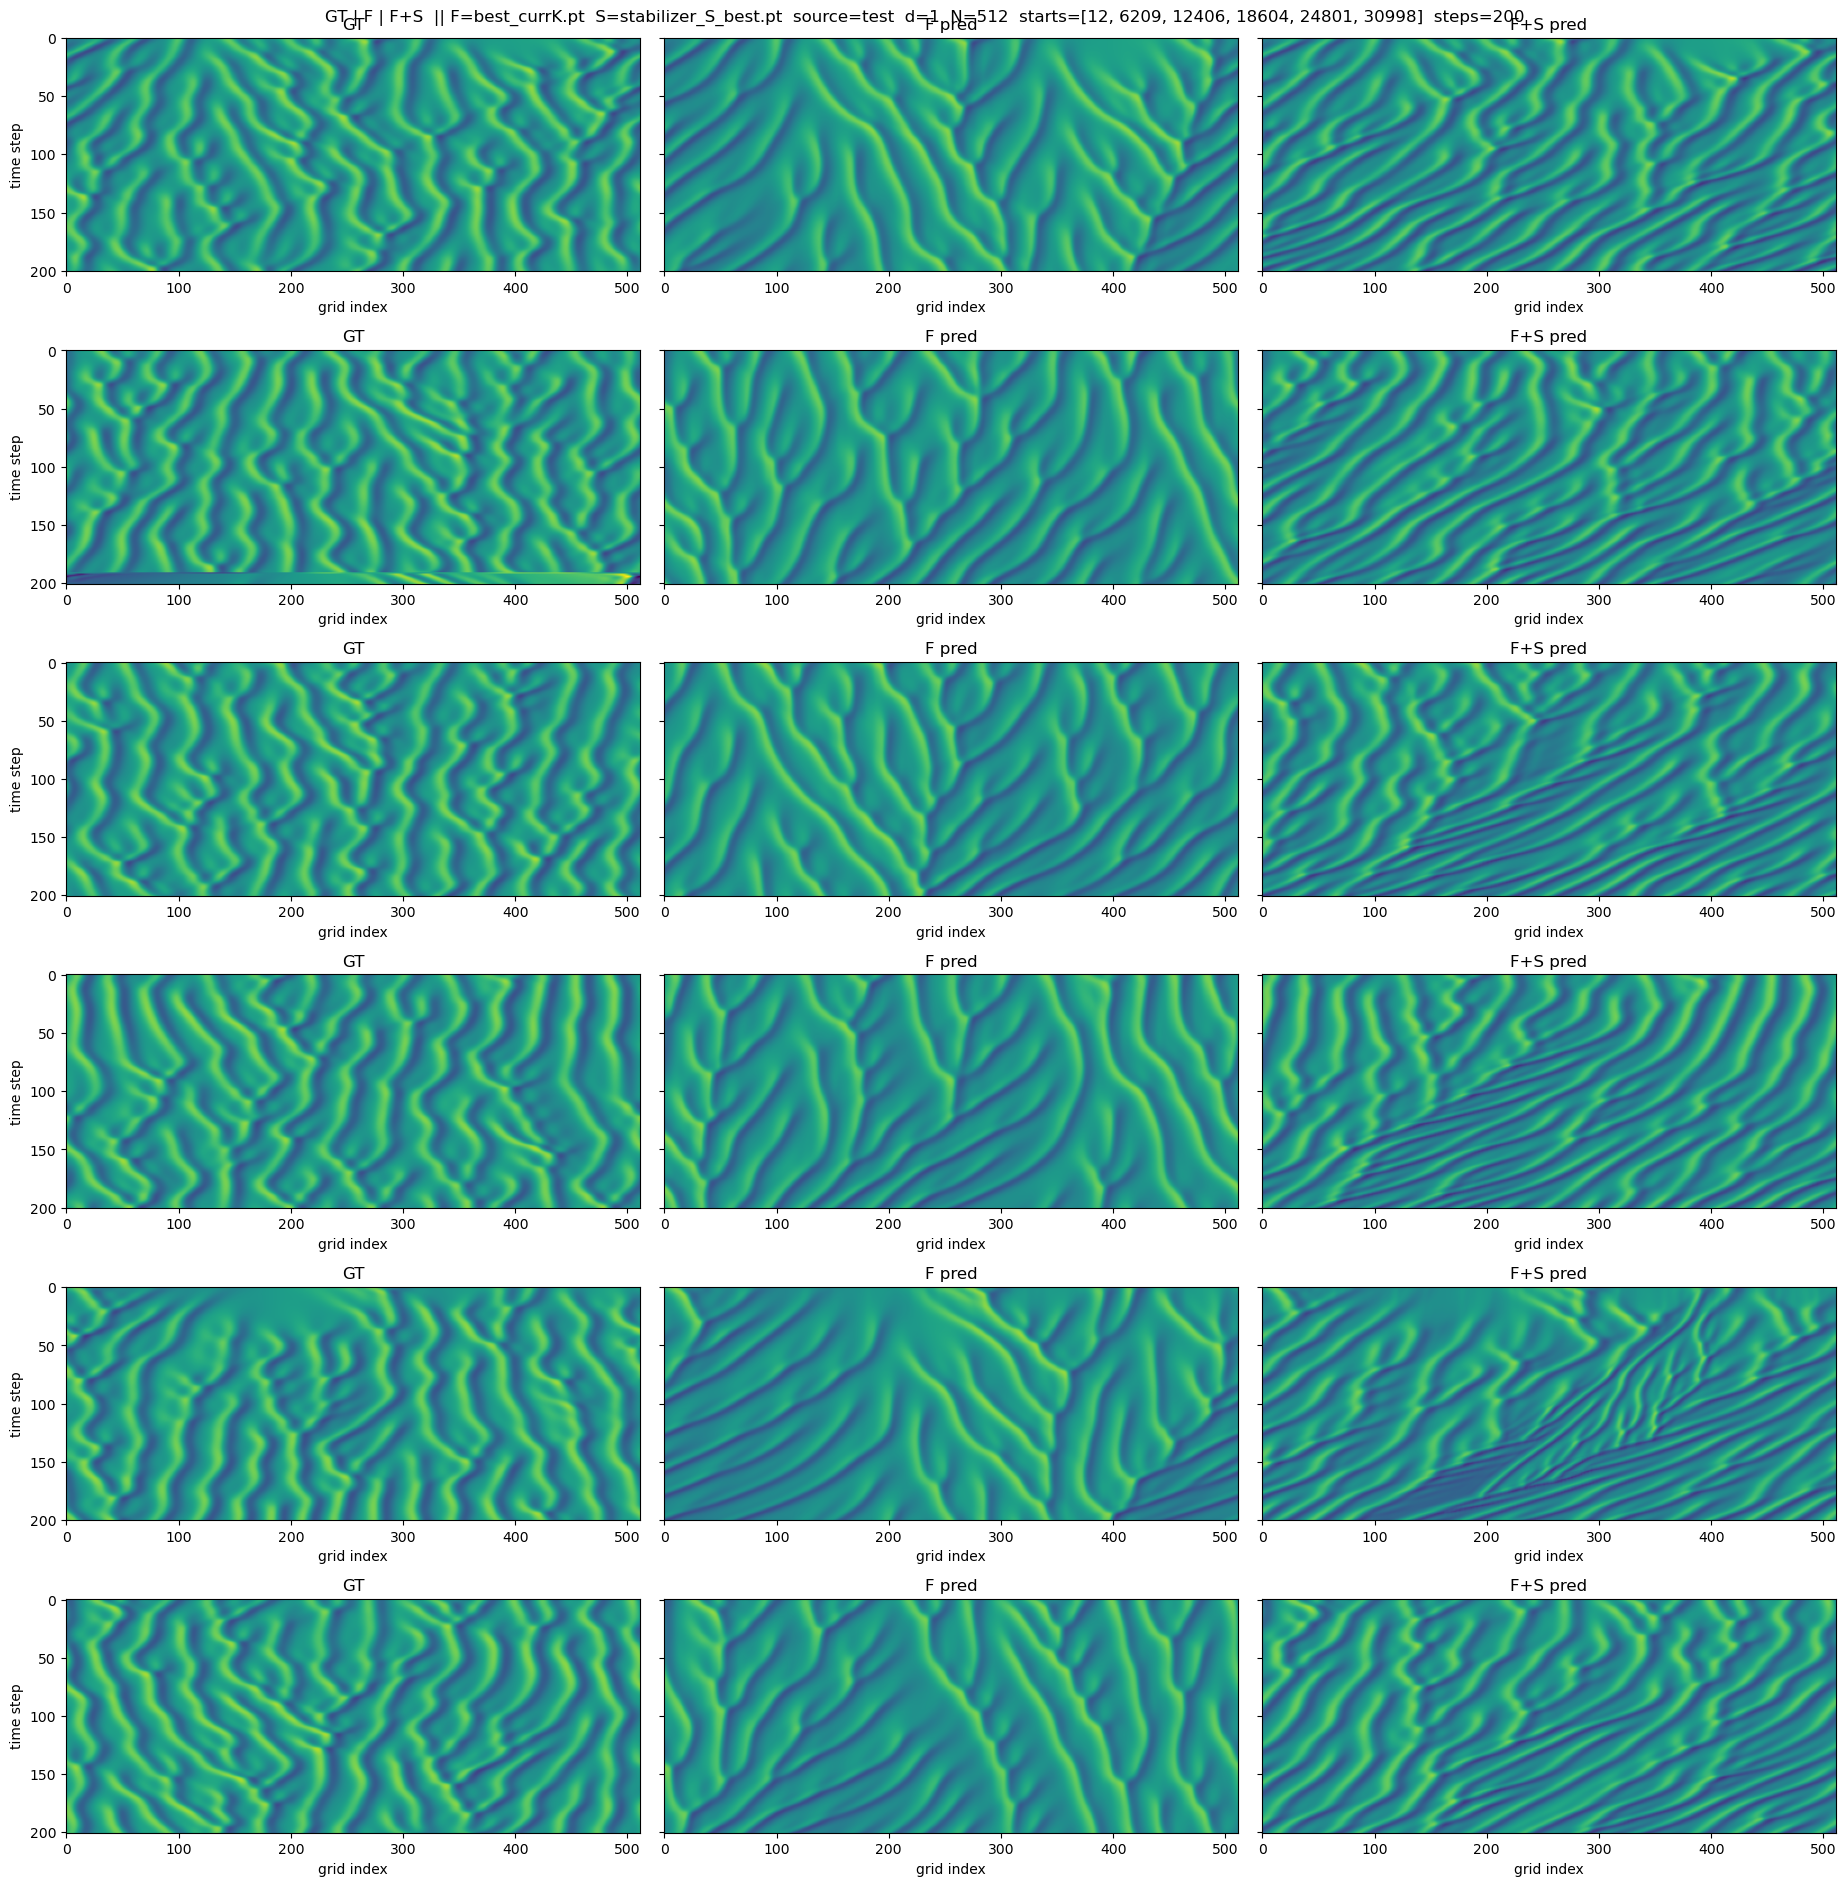

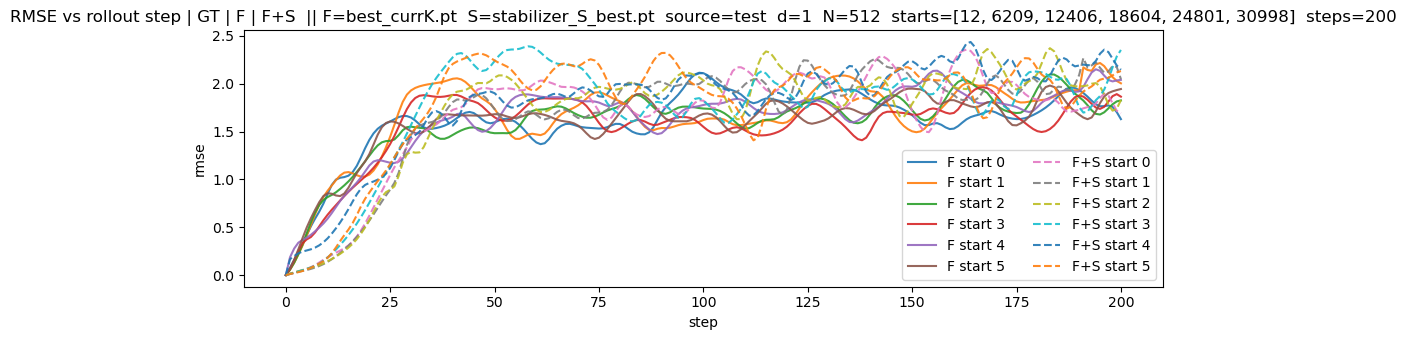

[done]


In [8]:
# ============================================
# Standalone (final): ALWAYS run S (if found) and plot 3 columns:
#   GT  |  F pred  |  F+S pred
# ============================================

import math
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# -----------------------
# user knobs
# -----------------------
DATA_DIR = Path("/scratch/pp3051/weather")

# folder where you saved stabilizer artifacts
RUN_DIR = Path("runs_exp8F_exp81GAN")

# fallback forecaster ckpt if RUN_DIR doesn't contain F ckpt
FORECASTER_FALLBACK_CKPT = Path("/scratch/pp3051/weather/runs_grid_agnostic_closed_loop_exp8_stable/best_currK.pt")

DIVISORS = [1]  # can be [1,2,4]

START_OFFSET = 10
ROLLOUT_STEPS = 200
ONE_STEP_SAMPLES = 4096

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

ROLL_SOURCE = "test"   # "test" recommended; or "all"
N_STARTS = 6
START_MODE = "spaced"  # "spaced" or "random"
START_SEED = 0
START_INDICES = None

# Stabilizer controls
REQUIRE_STABILIZER = True  # if True and S not found -> raise error
# optional direct path override (use this if your filename is different)
STAB_CKPT_PATH_OVERRIDE = None  # e.g. RUN_DIR/"stabilizer_step20000.pt"

# search these inside RUN_DIR if override not provided
STAB_CKPT_CANDIDATES = [
    "stabilizer_S_best.pt",
    "stabilizer_best.pt",
    "stabilizer_S_last.pt",
    "stabilizer_S_final.pt",
]
DU_CORR_CLIP_N = 2.0

# reproducibility
SEED = 1337
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# -----------------------
# utilities
# -----------------------
def pick_best_ckpt(run_dir: Path) -> Path:
    for name in ["best_currK.pt", "best_one_step.pt", "last.pt"]:
        p = run_dir / name
        if p.exists():
            return p
    raise FileNotFoundError(f"No forecaster checkpoint found in {run_dir}")

def find_first_existing(run_dir: Path, names):
    for n in names:
        p = run_dir / n
        if p.exists():
            return p
    step_ckpts = sorted(run_dir.glob("stabilizer_step*.pt"))
    if step_ckpts:
        return step_ckpts[-1]
    return None

def extract_state_dict(ckpt_obj):
    if isinstance(ckpt_obj, dict):
        for k in ["model", "state_dict", "model_state_dict", "net", "network"]:
            if k in ckpt_obj and isinstance(ckpt_obj[k], dict):
                return ckpt_obj[k]
        if any(torch.is_tensor(v) for v in ckpt_obj.values()):
            return ckpt_obj
    raise RuntimeError("Could not extract state_dict from checkpoint")

def strip_prefixes(sd: dict) -> dict:
    out = {}
    for k, v in sd.items():
        nk = k
        for pref in ["_orig_mod.", "module.", "model.", "forecaster."]:
            if nk.startswith(pref):
                nk = nk[len(pref):]
        out[nk] = v
    return out

def try_load_x_t(data_dir: Path):
    x = None
    t = None
    for cand in ["ks_spatial_grid.npy", "x.npy", "ks_spatial_grid1.npy"]:
        p = data_dir / cand
        if p.exists():
            x = np.load(p).astype(np.float32)
            break
    for cand in ["ks_time.npy", "t.npy"]:
        p = data_dir / cand
        if p.exists():
            t = np.load(p).astype(np.float32)
            break
    return x, t

def infer_Lx_dt(x, t):
    if x is not None and len(x) >= 2:
        Lx = float((x[1] - x[0]) * len(x))
    else:
        Lx = 2.0 * math.pi
    dt = None
    if t is not None and len(t) >= 2:
        dt = float(t[1] - t[0])
    return Lx, dt

def downsample_mean(u_batch: np.ndarray, divisor: int) -> np.ndarray:
    if divisor == 1:
        return u_batch.astype(np.float32, copy=False)
    B, N0 = u_batch.shape
    assert N0 % divisor == 0
    N = N0 // divisor
    return u_batch.reshape(B, N, divisor).mean(axis=2).astype(np.float32)

def posenc_from_x(x: np.ndarray, freqs):
    x = x.astype(np.float32)
    x01 = (x - x.min()) / max(1e-12, (x.max() - x.min()))
    feats = []
    for f in freqs:
        ang = 2.0 * np.pi * float(f) * x01
        feats.append(np.sin(ang))
        feats.append(np.cos(ang))
    return np.stack(feats, axis=0).astype(np.float32)

@torch.no_grad()
def rmse_t(a, b):
    return torch.sqrt(((a - b) ** 2).mean())

def compute_norms_from_X(X: np.ndarray, divisors):
    norms = {}
    N0 = X.shape[1]
    for d in divisors:
        N = N0 // d
        if d == 1:
            U = X
        else:
            T = X.shape[0]
            U = X.reshape(T, N, d).mean(axis=2).astype(np.float32, copy=False)

        u_mean = float(U.mean())
        u_std = float(U.std() + 1e-8)
        DU = U[1:] - U[:-1]
        du_mean = float(DU.mean())
        du_std = float(DU.std() + 1e-8)

        norms[d] = (
            torch.tensor(u_mean, device=DEVICE).view(1, 1, 1),
            torch.tensor(u_std, device=DEVICE).view(1, 1, 1),
            torch.tensor(du_mean, device=DEVICE).view(1, 1, 1),
            torch.tensor(du_std, device=DEVICE).view(1, 1, 1),
        )
        print(f"[norm] d={d} u_mean={u_mean:.4g} u_std={u_std:.4g} du_mean={du_mean:.4g} du_std={du_std:.4g}")
    return norms

def infer_norm_type_from_sd(sd: dict):
    return "batch" if any(".bn." in k for k in sd.keys()) else "layer"

def infer_F_shapes_from_sd(sd: dict):
    w = sd.get("stem.0.weight", None)
    if w is None:
        raise RuntimeError("F ckpt does not have stem.0.weight (wrong ckpt?)")
    hidden = int(w.shape[0])
    cin = int(w.shape[1])

    sw = sd.get("scalar_proj.0.weight", None)
    if sw is None:
        raise RuntimeError("F ckpt does not have scalar_proj.0.weight (wrong ckpt?)")
    scalar_dim = int(sw.shape[1])

    norm_type = infer_norm_type_from_sd(sd)
    return cin, scalar_dim, hidden, norm_type

def infer_freqs_from_cin(cin: int):
    n = (cin - 3) // 2
    if n <= 0:
        return tuple()
    return tuple(2**i for i in range(n))

def build_scalars(sdim: int, Lx: float, dt: float | None, dx: float):
    # heuristic: sdim=2 -> [Lx, dx]
    if sdim == 3:
        dtt = float(dt) if dt is not None else 0.0
        return [float(Lx), dtt, float(dx)]
    if sdim == 2:
        return [float(Lx), float(dx)]
    return [float(Lx)]

# -----------------------
# model definitions (exp8)
# -----------------------
class BatchOrLayerNorm1d(nn.Module):
    def __init__(self, num_features, norm_type="batch"):
        super().__init__()
        self.norm_type = norm_type
        if norm_type == "batch":
            self.bn = nn.BatchNorm1d(num_features)
            self.ln = None
        elif norm_type == "layer":
            self.ln = nn.LayerNorm(num_features)
            self.bn = None
        else:
            raise ValueError("norm_type must be 'batch' or 'layer'")

    def forward(self, x):
        if self.norm_type == "batch":
            return self.bn(x)
        x_perm = x.permute(0, 2, 1)
        x_norm = self.ln(x_perm)
        return x_norm.permute(0, 2, 1)

class ResidualDilated1D(nn.Module):
    def __init__(self, ch, d, norm_type, dropout_p):
        super().__init__()
        self.conv1 = nn.Conv1d(ch, ch, 3, padding=d, dilation=d, padding_mode="circular", bias=False)
        self.norm1 = BatchOrLayerNorm1d(ch, norm_type=norm_type)
        self.act1  = nn.SiLU(inplace=True)
        self.drop1 = nn.Dropout(p=dropout_p)

        self.conv2 = nn.Conv1d(ch, ch, 3, padding=1, dilation=1, padding_mode="circular", bias=False)
        self.norm2 = BatchOrLayerNorm1d(ch, norm_type=norm_type)
        self.act2  = nn.SiLU(inplace=True)
        self.drop2 = nn.Dropout(p=dropout_p)

    def forward(self, x):
        y = self.drop1(self.act1(self.norm1(self.conv1(x))))
        y = self.drop2(self.norm2(self.conv2(y)))
        return self.act2(x + y)

class GridAgnostic1D(nn.Module):
    def __init__(self, cin, scalar_dim, hidden=96, norm_type="batch", dropout_p=0.0, du_clip_n=5.0):
        super().__init__()
        self.du_clip_n = float(du_clip_n)

        self.stem = nn.Sequential(
            nn.Conv1d(cin, hidden, 3, padding=1, padding_mode="circular", bias=False),
            BatchOrLayerNorm1d(hidden, norm_type=norm_type),
            nn.SiLU(inplace=True),
            nn.Dropout(p=dropout_p),
        )
        self.b1 = ResidualDilated1D(hidden, 1, norm_type, dropout_p)
        self.b2 = ResidualDilated1D(hidden, 2, norm_type, dropout_p)
        self.b3 = ResidualDilated1D(hidden, 4, norm_type, dropout_p)
        self.b4 = ResidualDilated1D(hidden, 8, norm_type, dropout_p)
        self.b5 = ResidualDilated1D(hidden, 16, norm_type, dropout_p)

        self.scalar_proj = nn.Sequential(
            nn.Linear(scalar_dim, 128),
            nn.SiLU(inplace=True),
            nn.Dropout(p=dropout_p),
            nn.Linear(128, 32),
            nn.SiLU(inplace=True),
        )
        self.head = nn.Sequential(
            nn.Conv1d(hidden + 32, hidden, 1),
            BatchOrLayerNorm1d(hidden, norm_type=norm_type),
            nn.SiLU(inplace=True),
            nn.Dropout(p=dropout_p),
            nn.Conv1d(hidden, 1, 1),
        )

    def forward(self, profiles, scalars):
        h = self.stem(profiles)
        h = self.b5(self.b4(self.b3(self.b2(self.b1(h)))))
        B, C, L = h.shape
        s = self.scalar_proj(scalars)[:, :, None].expand(B, 32, L)
        h = torch.cat([h, s], dim=1)
        out = self.head(h)
        c = self.du_clip_n
        if c > 0:
            out = c * torch.tanh(out / c)
        return out

class Stabilizer1D(nn.Module):
    def __init__(self, cin_hist, scalar_dim, hidden=96, norm_type="batch", dropout_p=0.0, du_corr_clip_n=2.0):
        super().__init__()
        self.du_corr_clip_n = float(du_corr_clip_n)

        self.stem = nn.Sequential(
            nn.Conv1d(cin_hist, hidden, 3, padding=1, padding_mode="circular", bias=False),
            BatchOrLayerNorm1d(hidden, norm_type=norm_type),
            nn.SiLU(inplace=True),
            nn.Dropout(p=dropout_p),
        )
        self.b1 = ResidualDilated1D(hidden, 1, norm_type, dropout_p)
        self.b2 = ResidualDilated1D(hidden, 2, norm_type, dropout_p)
        self.b3 = ResidualDilated1D(hidden, 4, norm_type, dropout_p)
        self.b4 = ResidualDilated1D(hidden, 8, norm_type, dropout_p)

        self.scalar_proj = nn.Sequential(
            nn.Linear(scalar_dim, 64),
            nn.SiLU(inplace=True),
            nn.Dropout(p=dropout_p),
            nn.Linear(64, 16),
            nn.SiLU(inplace=True),
        )
        self.head = nn.Sequential(
            nn.Conv1d(hidden + 16, hidden, 1),
            BatchOrLayerNorm1d(hidden, norm_type=norm_type),
            nn.SiLU(inplace=True),
            nn.Dropout(p=dropout_p),
            nn.Conv1d(hidden, 1, 1),
        )

    def forward(self, x, scalars):
        h = self.stem(x)
        h = self.b4(self.b3(self.b2(self.b1(h))))
        B, C, N = h.shape
        s = self.scalar_proj(scalars)[:, :, None].expand(B, 16, N)
        h = torch.cat([h, s], dim=1)
        du_corr_n = self.head(h)
        c = self.du_corr_clip_n
        if c > 0:
            du_corr_n = c * torch.tanh(du_corr_n / c)
        return du_corr_n

# -----------------------
# load data
# -----------------------
for f in ["X_train.npy", "X_val.npy", "X_test.npy"]:
    if not (DATA_DIR / f).exists():
        raise FileNotFoundError(f"Missing {f} in {DATA_DIR}")

Xtr = np.load(DATA_DIR / "X_train.npy").astype(np.float32, copy=False)
Xva = np.load(DATA_DIR / "X_val.npy").astype(np.float32, copy=False)
Xte = np.load(DATA_DIR / "X_test.npy").astype(np.float32, copy=False)

X_all = np.concatenate([Xtr, Xva, Xte], axis=0).astype(np.float32, copy=False)
X_roll = Xte if ROLL_SOURCE == "test" else X_all
print(f"[roll] source={ROLL_SOURCE} frames={X_roll.shape[0]} N0={X_roll.shape[1]}")

x_arr, t_arr = try_load_x_t(DATA_DIR)
Lx, dt = infer_Lx_dt(x_arr, t_arr)
print(f"[grid] Lx={Lx} dt={dt}")

print("[norms] computing from X_train")
norms = compute_norms_from_X(Xtr, DIVISORS)

# -----------------------
# load forecaster F
# -----------------------
try:
    ckpt_path = pick_best_ckpt(RUN_DIR)
    print(f"[eval] using forecaster ckpt from RUN_DIR: {ckpt_path}")
except Exception:
    ckpt_path = FORECASTER_FALLBACK_CKPT
    print(f"[eval] using forecaster ckpt fallback: {ckpt_path}")

ckptF = torch.load(ckpt_path, map_location="cpu")
sdF = strip_prefixes(extract_state_dict(ckptF))

Cin, Sdim, hidden, norm_type = infer_F_shapes_from_sd(sdF)
FREQS = infer_freqs_from_cin(Cin)
pe_ch = 2 * len(FREQS)
du_clip_n = float(ckptF.get("du_clip_n", 5.0)) if isinstance(ckptF, dict) else 5.0

print(f"[F meta] Cin={Cin} Sdim={Sdim} hidden={hidden} norm_type={norm_type} freqs={FREQS} du_clip_n={du_clip_n}")

modelF = GridAgnostic1D(cin=Cin, scalar_dim=Sdim, hidden=hidden, norm_type=norm_type, dropout_p=0.0, du_clip_n=du_clip_n).to(DEVICE)
missing, unexpected = modelF.load_state_dict(sdF, strict=False)
print(f"[eval] F loaded. missing={len(missing)} unexpected={len(unexpected)}")
modelF.eval()

# -----------------------
# load stabilizer S (required)
# -----------------------
modelS = None
useS = False
INCLUDE_DU_BASE_RUNTIME = True

if STAB_CKPT_PATH_OVERRIDE is not None:
    stab_ckpt_path = Path(STAB_CKPT_PATH_OVERRIDE)
else:
    stab_ckpt_path = find_first_existing(RUN_DIR, STAB_CKPT_CANDIDATES)

if stab_ckpt_path is None or (not stab_ckpt_path.exists()):
    if REQUIRE_STABILIZER:
        raise FileNotFoundError(f"Could not find stabilizer ckpt in {RUN_DIR}. Set STAB_CKPT_PATH_OVERRIDE or drop REQUIRE_STABILIZER.")
    print("[eval] no stabilizer found, will plot only GT and F")
else:
    print(f"[eval] loading stabilizer from: {stab_ckpt_path}")
    ckS = torch.load(stab_ckpt_path, map_location="cpu")

    # accept either:
    #  (A) full dict with key 'S'
    #  (B) raw state_dict
    if isinstance(ckS, dict) and "S" in ckS and isinstance(ckS["S"], dict):
        sdS = ckS["S"]
    else:
        sdS = extract_state_dict(ckS)
    sdS = strip_prefixes(sdS)

    wS = sdS.get("stem.0.weight", None)
    if wS is None:
        raise RuntimeError("S ckpt missing stem.0.weight")
    cin_S = int(wS.shape[1])
    hidden_S = int(wS.shape[0])
    swS = sdS.get("scalar_proj.0.weight", None)
    if swS is None:
        raise RuntimeError("S ckpt missing scalar_proj.0.weight")
    Sdim_S = int(swS.shape[1])
    norm_type_S = infer_norm_type_from_sd(sdS)

    INCLUDE_DU_BASE_RUNTIME = (cin_S == (3 + pe_ch + 1))
    if cin_S == (3 + pe_ch):
        INCLUDE_DU_BASE_RUNTIME = False

    du_corr_clip_n = DU_CORR_CLIP_N
    if isinstance(ckS, dict) and "du_corr_clip_n" in ckS:
        du_corr_clip_n = float(ckS["du_corr_clip_n"])

    print(f"[S meta] cin_S={cin_S} hidden_S={hidden_S} Sdim_S={Sdim_S} norm_type_S={norm_type_S} include_du_base={INCLUDE_DU_BASE_RUNTIME} du_corr_clip_n={du_corr_clip_n}")

    modelS = Stabilizer1D(cin_hist=cin_S, scalar_dim=Sdim_S, hidden=hidden_S, norm_type=norm_type_S, dropout_p=0.0, du_corr_clip_n=du_corr_clip_n).to(DEVICE)
    m2, u2 = modelS.load_state_dict(sdS, strict=False)
    print(f"[eval] S loaded. missing={len(m2)} unexpected={len(u2)}")
    modelS.eval()
    useS = True

# -----------------------
# geometry cache
# -----------------------
_cache = {}

def get_geom_cached(divisor: int):
    key = ("geom", divisor)
    if key in _cache:
        return _cache[key]

    N0 = X_all.shape[1]
    assert N0 % divisor == 0
    N = N0 // divisor
    dx = float(Lx) / float(N)
    x = (np.arange(N, dtype=np.float32) + 0.5) * dx

    pe = torch.from_numpy(posenc_from_x(x, FREQS)[None]).to(DEVICE)  # [1,pe_ch,N]
    scal = build_scalars(Sdim, Lx=Lx, dt=dt, dx=dx)
    scalars = torch.tensor(scal, dtype=torch.float32, device=DEVICE)[None, :]

    _cache[key] = (N, dx, pe, scalars)
    return _cache[key]

# -----------------------
# one-step RMSE (prints F and F+S)
# -----------------------
@torch.no_grad()
def one_step_rmse(divisor: int, n_samples: int = 4096, seed: int = 0, use_stab: bool = False):
    rng = np.random.default_rng(seed)
    N_total = X_all.shape[0]
    lo = 2
    hi = N_total - 2
    idx = rng.integers(lo, hi + 1, size=min(n_samples, hi - lo + 1))

    X0 = downsample_mean(X_all[idx - 2], divisor)
    X1 = downsample_mean(X_all[idx - 1], divisor)
    Xt = downsample_mean(X_all[idx], divisor)
    Y1 = downsample_mean(X_all[idx + 1], divisor)

    N, dx, pe, scalars1 = get_geom_cached(divisor)
    u_mean, u_std, du_mean, du_std = norms[divisor]

    u_tm2 = torch.from_numpy(X0[:, None, :]).to(DEVICE)
    u_tm1 = torch.from_numpy(X1[:, None, :]).to(DEVICE)
    u_t   = torch.from_numpy(Xt[:, None, :]).to(DEVICE)
    y_tp1 = torch.from_numpy(Y1[:, None, :]).to(DEVICE)

    B = u_t.shape[0]
    peB = pe.repeat(B, 1, 1)
    scalarsB = scalars1.repeat(B, 1)

    u_tm2_n = (u_tm2 - u_mean) / u_std
    u_tm1_n = (u_tm1 - u_mean) / u_std
    u_t_n   = (u_t   - u_mean) / u_std

    prof = torch.cat([u_tm2_n, u_tm1_n, u_t_n, peB], dim=1)
    du_base_n = modelF(prof, scalarsB)
    du_base   = du_base_n * du_std + du_mean

    du_tot = du_base
    if use_stab and useS and modelS is not None:
        if INCLUDE_DU_BASE_RUNTIME:
            xS = torch.cat([u_tm2_n, u_tm1_n, u_t_n, du_base_n, peB], dim=1)
        else:
            xS = torch.cat([u_tm2_n, u_tm1_n, u_t_n, peB], dim=1)
        du_corr_n = modelS(xS, scalarsB)
        du_corr = du_corr_n * du_std
        du_tot = du_base + du_corr

    y_hat = u_t + du_tot
    return float(rmse_t(y_hat, y_tp1).item())

print("[one-step] rmse")
for d in DIVISORS:
    rF = one_step_rmse(d, n_samples=ONE_STEP_SAMPLES, seed=0, use_stab=False)
    print(f"  GT vs F     | d={d} N={X_all.shape[1]//d} rmse={rF:.6f}")
    if useS:
        rFS = one_step_rmse(d, n_samples=ONE_STEP_SAMPLES, seed=0, use_stab=True)
        print(f"  GT vs F+S   | d={d} N={X_all.shape[1]//d} rmse={rFS:.6f}")

# -----------------------
# rollout functions
# -----------------------
@torch.no_grad()
def rollout_from_index(i0: int, steps: int, divisor: int, X_seq: np.ndarray, use_stab: bool = False):
    N, dx, pe, scalars1 = get_geom_cached(divisor)
    u_mean, u_std, du_mean, du_std = norms[divisor]

    def down1(u1):
        u1 = u1.astype(np.float32, copy=False)[None, :]
        return downsample_mean(u1, divisor)[0]

    assert i0 >= 2
    assert i0 + steps + 1 < X_seq.shape[0]

    u_tm2 = torch.from_numpy(down1(X_seq[i0 - 2])[None, None, :]).to(DEVICE)
    u_tm1 = torch.from_numpy(down1(X_seq[i0 - 1])[None, None, :]).to(DEVICE)
    u_t   = torch.from_numpy(down1(X_seq[i0      ])[None, None, :]).to(DEVICE)

    preds = [u_t.squeeze(0).squeeze(0).cpu().numpy()]
    truth = [down1(X_seq[i0]).copy()]

    rmse_curve = [0.0]

    for k in range(steps):
        u_tm2_n = (u_tm2 - u_mean) / u_std
        u_tm1_n = (u_tm1 - u_mean) / u_std
        u_t_n   = (u_t   - u_mean) / u_std

        prof = torch.cat([u_tm2_n, u_tm1_n, u_t_n, pe], dim=1)
        du_base_n = modelF(prof, scalars1)
        du_base   = du_base_n * du_std + du_mean

        du_tot = du_base
        if use_stab and useS and modelS is not None:
            if INCLUDE_DU_BASE_RUNTIME:
                xS = torch.cat([u_tm2_n, u_tm1_n, u_t_n, du_base_n, pe], dim=1)
            else:
                xS = torch.cat([u_tm2_n, u_tm1_n, u_t_n, pe], dim=1)
            du_corr_n = modelS(xS, scalars1)
            du_corr = du_corr_n * du_std
            du_tot = du_base + du_corr

        u_next = u_t + du_tot

        u_true_np = down1(X_seq[i0 + k + 1]).copy()
        u_true = torch.from_numpy(u_true_np[None, None, :]).to(DEVICE)

        rmse_curve.append(float(rmse_t(u_next, u_true).item()))

        u_tm2, u_tm1, u_t = u_tm1, u_t, u_next
        preds.append(u_next.squeeze(0).squeeze(0).cpu().numpy())
        truth.append(u_true_np)

    return np.stack(preds, 0), np.stack(truth, 0), np.array(rmse_curve, dtype=np.float32)

def pick_start_indices(X_seq: np.ndarray, steps: int, n_starts: int, mode: str, seed: int, start_offset: int):
    n = X_seq.shape[0]
    lo = max(2 + int(start_offset), 2)
    hi = n - int(steps) - 2
    if hi < lo:
        return []
    if mode == "spaced":
        if n_starts <= 1:
            return [int((lo + hi) // 2)]
        xs = np.linspace(lo, hi, n_starts)
        out = []
        for v in xs:
            iv = int(round(float(v)))
            if len(out) == 0 or iv != out[-1]:
                out.append(iv)
        return out
    if mode == "random":
        rng = np.random.default_rng(seed)
        return [int(x) for x in rng.integers(lo, hi + 1, size=n_starts)]
    raise ValueError("mode must be 'spaced' or 'random'")

def plot_multi_rollouts_gt_f_fs(truth_list, predF_list, predFS_list, rmseF_list, rmseFS_list, title):
    # ALWAYS 3 columns: GT | F | F+S
    n = len(truth_list)
    cols = 3

    vmin = min(float(t.min()) for t in truth_list)
    vmax = max(float(t.max()) for t in truth_list)
    vmin = min(vmin, min(float(p.min()) for p in predF_list), min(float(p.min()) for p in predFS_list))
    vmax = max(vmax, max(float(p.max()) for p in predF_list), max(float(p.max()) for p in predFS_list))

    fig, axes = plt.subplots(n, cols, figsize=(6.2 * cols, 3.2 * n), sharey=True)
    if n == 1:
        axes = np.array([axes])

    for i in range(n):
        axes[i, 0].imshow(truth_list[i], aspect="auto", vmin=vmin, vmax=vmax)
        axes[i, 0].set_title("GT")

        axes[i, 1].imshow(predF_list[i], aspect="auto", vmin=vmin, vmax=vmax)
        axes[i, 1].set_title("F pred")

        axes[i, 2].imshow(predFS_list[i], aspect="auto", vmin=vmin, vmax=vmax)
        axes[i, 2].set_title("F+S pred")

        axes[i, 0].set_ylabel("time step")
        for c in range(cols):
            axes[i, c].set_xlabel("grid index")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 3.5))
    for i in range(n):
        plt.plot(rmseF_list[i], label=f"F start {i}", alpha=0.9)
    for i in range(n):
        plt.plot(rmseFS_list[i], label=f"F+S start {i}", alpha=0.9, linestyle="--")
    plt.title(f"RMSE vs rollout step | {title}")
    plt.xlabel("step")
    plt.ylabel("rmse")
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.show()

# -----------------------
# run rollouts (GT | F | F+S)
# -----------------------
print("[rollout] closed-loop")

if REQUIRE_STABILIZER and not useS:
    raise RuntimeError("REQUIRE_STABILIZER=True but S is not loaded. Fix STAB_CKPT_PATH_OVERRIDE or put S ckpt in RUN_DIR.")

n_roll = X_roll.shape[0]
max_steps_possible = (n_roll - 2) - (2 + START_OFFSET) - 1
steps_use = min(int(ROLLOUT_STEPS), int(max(10, max_steps_possible)))
if steps_use < 10:
    raise RuntimeError(f"Not enough frames for rollout: n_roll={n_roll}, START_OFFSET={START_OFFSET}")

for d in DIVISORS:
    starts = [int(x) for x in START_INDICES] if START_INDICES is not None else pick_start_indices(
        X_roll, steps_use, N_STARTS, START_MODE, START_SEED, START_OFFSET
    )
    if len(starts) == 0:
        raise RuntimeError("No valid start indices found (try reducing ROLLOUT_STEPS or START_OFFSET).")

    truth_list, predF_list, rmseF_list = [], [], []
    predFS_list, rmseFS_list = [], []

    for i0 in starts:
        predsF, truth, rmseF = rollout_from_index(i0=i0, steps=steps_use, divisor=d, X_seq=X_roll, use_stab=False)
        predsFS, truth2, rmseFS = rollout_from_index(i0=i0, steps=steps_use, divisor=d, X_seq=X_roll, use_stab=True)

        truth_list.append(truth)
        predF_list.append(predsF)
        rmseF_list.append(rmseF)

        predFS_list.append(predsFS)
        rmseFS_list.append(rmseFS)

    title = f"GT | F | F+S  || F={ckpt_path.name}  S={stab_ckpt_path.name}  source={ROLL_SOURCE}  d={d}  N={truth_list[0].shape[1]}  starts={starts}  steps={steps_use}"
    plot_multi_rollouts_gt_f_fs(truth_list, predF_list, predFS_list, rmseF_list, rmseFS_list, title)

print("[done]")
